# Project-9: Social Media Usage & Teen Mental Health

## Task 1: Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Admin\Desktop\github\python-data-science-handbook\Projects\data\Teen_Mental_Health_Dataset.csv")
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [2]:
df.shape

(1200, 13)

In [3]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [4]:
df.select_dtypes(include="number").columns

Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [5]:
df.select_dtypes(include="object").columns

Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='object')

## Task 2: Data Cleaning & Preprocessing

In [6]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Project 3: Feature Engineering

In [8]:
def social_categories(hours):
    if hours < 2:
        return "Low"
    elif hours <= 4:
        return "Moderate"
    else:
        return "Heavy"

social_categories

<function __main__.social_categories(hours)>

In [9]:
df["daily_social_media_hours_category"] = df["daily_social_media_hours"].apply(social_categories)
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,daily_social_media_hours_category
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,Heavy
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,Low
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,Low
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0,Heavy
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0,Heavy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0,Heavy
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0,Moderate
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0,Low
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0,Moderate


In [10]:
df["Sleep Deficit"] = 8 - df["sleep_hours"]

## Project 4: Visualizing Behavioral Impacts

Text(0, 0.5, 'Count')

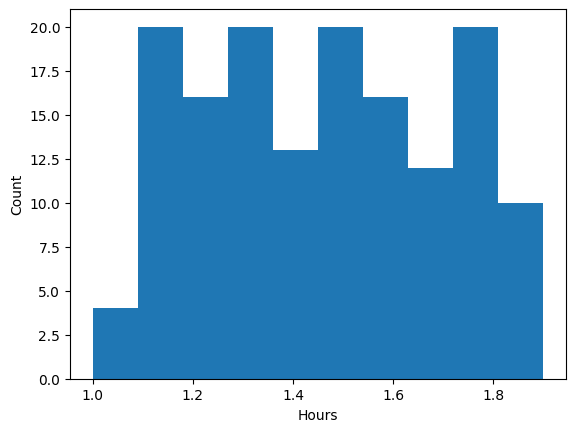

In [ ]:
low_users = df[df["daily_social_media_hours_category"] == "Low"]
plt.hist(low_users["daily_social_media_hours"])
plt.xlabel("Hours")
plt.ylabel("Count")

In [ ]:
moderate_users = df[df["daily_social_media_hours_category"] == "Moderate"]
plt.hist(low_users["daily_social_media_hours"])
plt.xlabel("Hours")
plt.ylabel("Count")

In [13]:
low_users

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,daily_social_media_hours_category,Sleep Deficit
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,Low,0.0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,Low,0.4
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0,Low,3.1
16,13,male,1.5,Both,4.2,1.4,2.59,0.5,high,4,5,8,0,Low,3.8
19,14,female,1.2,Instagram,7.6,1.0,3.85,0.8,high,8,4,6,0,Low,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1167,13,male,1.3,TikTok,4.4,0.9,2.99,0.0,high,8,2,5,0,Low,3.6
1184,19,male,1.4,Both,4.5,2.3,3.90,0.0,medium,2,8,10,0,Low,3.5
1186,18,male,1.6,Both,5.4,2.0,3.20,1.8,low,8,8,3,0,Low,2.6
1189,14,female,1.6,TikTok,4.8,2.4,2.97,1.9,low,9,9,10,0,Low,3.2


<Axes: xlabel='stress_level', ylabel='daily_social_media_hours_category'>

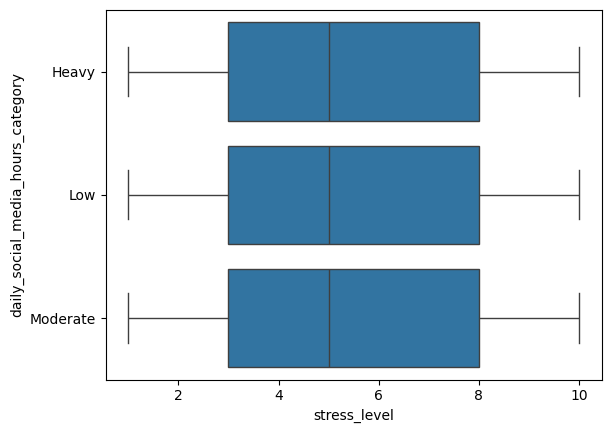

In [11]:
import seaborn as sns
sns.boxplot(data=df, x="stress_level", y="daily_social_media_hours_category")
